# NB06 — Phase 1B Full Atlas: Null Model + Scoring

**Project**: Gene Function Ecological Agora — Innovation Atlas Across the Bacterial Tree  
**Phase**: 1B — Full GTDB scale  
**Purpose**: Build the multi-rank producer + consumer null models on the full Phase 1B substrate (18,989 species × 100,192 UniRef50s) with M1 rank-stratified parent ranks for the consumer null. Compute per-(rank, clade, UniRef) producer + consumer z-scores. Materialize lookups for NB07 (Bacteroidota PUL hypothesis test) and NB08 (Phase 1B → Phase 2 gate).

## What changes from Phase 1A NB02 v2

Per RESEARCH_PLAN.md v2.3 + DESIGN_NOTES.md v2.2:

- **M1 rank-stratified parent ranks** for the consumer null (was the headline methodological revision):
  - genus → family parent
  - family → order parent
  - order → class parent
  - class → phylum parent
  - (phylum → no parent, consumer null skipped at top rank)
  Phase 1A used parent_rank=phylum for all child ranks; that masked intra-phylum HGT (AMR consumer z = −4.4 to −4.8). Rank-stratified parents make the consumer null sensitive to HGT events at the rank where they occur.
- **Substrate is 75× larger than Phase 1A pilot**: 1.54M presence rows in long-format. Matrix builds use sparse representations where possible.
- **HIGH 2 effect-size reporting**: producer scores reported with raw paralog count means alongside z-scores in NB07.

## Inputs

- `data/p1b_full_species.tsv` — 18,989 species with rank scaffold + quality + annotation density
- `data/p1b_full_uniref50.tsv` — 100,192 UniRef50s with control_class + flags
- `data/p1b_full_extract_local.parquet` — 1.54M (species, UniRef50, paralog_count) presence rows

## Outputs

- `data/p1b_null_producer_lookup.parquet` — per-(rank, clade, prevalence_bin) producer-null cohort moments
- `data/p1b_null_consumer_lookup.parquet` — per-(rank, UniRef50) consumer z-score with rank-stratified parents (M1)
- `data/p1b_uniref_prevalence_bin.tsv` — per-(rank, UniRef50) prevalence bin
- `data/p1b_full_scores.parquet` — per-(rank, clade, UniRef50) producer + consumer z scores (NB07 input)
- `data/p1b_full_null_diagnostics.json` — calibration log
- `figures/p1b_null_per_rank_distributions.png` — multi-rank null diagnostic figure

**Estimated runtime**: 10–25 min depending on permutation count and matrix size.

## Setup

In [1]:
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

PROJECT_ROOT = Path("/home/aparkin/BERIL-research-observatory/projects/gene_function_ecological_agora")
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

N_PERMUTATIONS = 500   # halved from Phase 1A's 1000 because matrix is 75x larger
N_PREVALENCE_BINS = 10

RANKS = ["genus", "family", "order", "class", "phylum"]
# M1: rank-stratified parents — for each child rank, the parent rank is one level up
PARENT_RANK = {
    "genus": "family",
    "family": "order",
    "order": "class",
    "class": "phylum",
    "phylum": None,  # no parent; consumer null undefined at top
}

diagnostics = {
    "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "seed": RNG_SEED,
    "n_permutations": N_PERMUTATIONS,
    "n_prevalence_bins": N_PREVALENCE_BINS,
    "ranks": RANKS,
    "parent_rank_stratified": {r: PARENT_RANK[r] for r in RANKS},
}
print(json.dumps(diagnostics, indent=2))

{
  "timestamp_utc": "2026-04-26T23:41:33Z",
  "seed": 42,
  "n_permutations": 500,
  "n_prevalence_bins": 10,
  "ranks": [
    "genus",
    "family",
    "order",
    "class",
    "phylum"
  ],
  "parent_rank_stratified": {
    "genus": "family",
    "family": "order",
    "order": "class",
    "class": "phylum",
    "phylum": null
  }
}


## Stage 1 — Load Phase 1B substrate

In [2]:
species_df = pd.read_csv(DATA_DIR / "p1b_full_species.tsv", sep="\t")
uniref_df = pd.read_csv(DATA_DIR / "p1b_full_uniref50.tsv", sep="\t")
extract_df = pd.read_parquet(DATA_DIR / "p1b_full_extract_local.parquet")

# Apply paralog fallback (option a from M4)
extract_df["paralog_count"] = np.where(
    extract_df["n_uniref90_present"] >= 1,
    extract_df["n_uniref90_present"],
    extract_df["n_gene_clusters"],
).astype(np.int32)
n_fallback = int((extract_df["n_uniref90_present"] < 1).sum())
diagnostics["frac_fallback_paralog"] = n_fallback / len(extract_df)

print(f"Species:  {species_df.shape}")
print(f"UniRef:   {uniref_df.shape}")
print(f"Extract:  {extract_df.shape} (fallback paralog used in {n_fallback:,} = {100*n_fallback/len(extract_df):.1f}% of rows)")

Species:  (18989, 24)
UniRef:   (100192, 12)
Extract:  (1539643, 6) (fallback paralog used in 253,527 = 16.5% of rows)


## Stage 2 — Build sparse species × UniRef matrices

At Phase 1B scale (18,989 × 100,192 = 1.9 B cells, 1.54 M nonzeros = 0.08% density), sparse matrices are mandatory.

In [3]:
species_ids = species_df["gtdb_species_clade_id"].tolist()
uniref_ids = uniref_df["uniref50_id"].tolist()
species_idx = {s: i for i, s in enumerate(species_ids)}
uniref_idx = {u: i for i, u in enumerate(uniref_ids)}
N_SPECIES = len(species_ids)
N_UREFS = len(uniref_ids)

# Build COO sparse matrices
ext_filtered = extract_df[
    extract_df["gtdb_species_clade_id"].isin(species_idx)
    & extract_df["uniref50_id"].isin(uniref_idx)
].copy()
ext_filtered["_si"] = ext_filtered["gtdb_species_clade_id"].map(species_idx).astype(np.int64)
ext_filtered["_ui"] = ext_filtered["uniref50_id"].map(uniref_idx).astype(np.int64)

M_par = sparse.coo_matrix(
    (ext_filtered["paralog_count"].values,
     (ext_filtered["_si"].values, ext_filtered["_ui"].values)),
    shape=(N_SPECIES, N_UREFS), dtype=np.int32,
).tocsr()
M_pres = (M_par > 0).astype(np.int8)

print(f"Sparse matrices: {N_SPECIES:,} × {N_UREFS:,}, nnz = {M_pres.nnz:,} (density {100*M_pres.nnz/(N_SPECIES*N_UREFS):.4f}%)")
diagnostics["matrix_density_pct"] = float(100*M_pres.nnz/(N_SPECIES*N_UREFS))
diagnostics["matrix_nnz"] = int(M_pres.nnz)

Sparse matrices: 18,989 × 100,192, nnz = 1,539,643 (density 0.0809%)


## Stage 3 — Multi-rank clade aggregation

In [4]:
def aggregate_to_rank(M_par_csr, M_pres_csr, rank_labels):
    """Aggregate species × UniRef sparse matrices to clade × UniRef.
    paralog: max paralog count across species in clade.
    presence: any species in clade has UniRef.
    Returns (M_clade_par, M_clade_pres, clade_ids)."""
    label_arr = np.array(rank_labels)
    unique_clades = sorted(set(label_arr) - {"unknown", None})
    K = len(unique_clades)
    if K == 0:
        return None, None, []
    clade_to_idx = {c: i for i, c in enumerate(unique_clades)}
    species_to_clade = np.array([clade_to_idx.get(c, -1) for c in label_arr])
    valid_mask = species_to_clade >= 0

    # Build aggregation: for each clade, max-paralog across species in clade
    # Use scipy sparse: build a clade-membership matrix and do max-aggregation row-wise
    M_par_dense_per_clade = sparse.lil_matrix((K, M_par_csr.shape[1]), dtype=np.int32)
    M_pres_per_clade = sparse.lil_matrix((K, M_pres_csr.shape[1]), dtype=np.int8)
    for sp_i in np.where(valid_mask)[0]:
        ki = species_to_clade[sp_i]
        sp_par_row = M_par_csr.getrow(sp_i).toarray().ravel()
        sp_pres_row = M_pres_csr.getrow(sp_i).toarray().ravel()
        # max-paralog: take element-wise max
        existing_par = M_par_dense_per_clade.getrow(ki).toarray().ravel()
        new_par = np.maximum(existing_par, sp_par_row)
        # Only update non-zero positions for sparsity
        diff_idx = np.where(new_par != existing_par)[0]
        for j in diff_idx:
            M_par_dense_per_clade[ki, j] = new_par[j]
        existing_pres = M_pres_per_clade.getrow(ki).toarray().ravel()
        new_pres = np.maximum(existing_pres, sp_pres_row)
        diff_idx2 = np.where(new_pres != existing_pres)[0]
        for j in diff_idx2:
            M_pres_per_clade[ki, j] = new_pres[j]
    return M_par_dense_per_clade.tocsr(), M_pres_per_clade.tocsr(), unique_clades

# That LIL approach is O(K × N) per row and slow. Let me use a faster vectorized approach.
# Use a clade-membership indicator matrix C [K × N_species], then:
#   M_clade_pres = (C @ M_pres > 0).astype(int8)   — presence: any species in clade
#   M_clade_par   = element-wise max via groupby on COO

def aggregate_to_rank_fast(M_par_csr, M_pres_csr, rank_labels):
    label_arr = np.array(rank_labels)
    unique_clades = sorted(set(label_arr) - {"unknown", None})
    if len(unique_clades) == 0:
        return None, None, []
    clade_to_idx = {c: i for i, c in enumerate(unique_clades)}
    species_to_clade = np.array([clade_to_idx.get(c, -1) for c in label_arr])
    valid_species = species_to_clade >= 0
    K = len(unique_clades)
    Nsp = M_par_csr.shape[0]
    # Indicator C [K × Nsp]
    rows = species_to_clade[valid_species]
    cols = np.where(valid_species)[0]
    data = np.ones(len(rows), dtype=np.int8)
    C = sparse.csr_matrix((data, (rows, cols)), shape=(K, Nsp))
    # Presence: C @ M_pres → counts; threshold to {0,1}
    M_clade_count = (C @ M_pres_csr.astype(np.int32)).tocsr()
    M_clade_pres = (M_clade_count > 0).astype(np.int8)
    # For paralog max: iterate over UniRef columns and per-clade max via per-row reduction
    # M_par is sparse → convert to COO and groupby-max
    coo = M_par_csr.tocoo()
    # Map species → clade for each entry
    sp_clade = species_to_clade[coo.row]
    valid_entries = sp_clade >= 0
    df = pd.DataFrame({
        "clade": sp_clade[valid_entries],
        "uref": coo.col[valid_entries],
        "paralog": coo.data[valid_entries].astype(np.int32),
    })
    grp = df.groupby(["clade", "uref"], sort=False)["paralog"].max().reset_index()
    M_clade_par = sparse.csr_matrix(
        (grp["paralog"].values, (grp["clade"].values, grp["uref"].values)),
        shape=(K, M_par_csr.shape[1]), dtype=np.int32,
    )
    return M_clade_par, M_clade_pres, unique_clades

rank_data = {}
for rank in RANKS:
    labels = species_df.set_index("gtdb_species_clade_id").reindex(species_ids)[rank].fillna("unknown").tolist()
    M_p, M_pr, clades = aggregate_to_rank_fast(M_par, M_pres, labels)
    rank_data[rank] = {
        "M_par": M_p, "M_pres": M_pr, "clade_ids": clades, "labels": labels,
    }
    K = len(clades) if clades else 0
    nnz = M_pr.nnz if M_pr is not None else 0
    print(f"  {rank:8s}: {K:5d} clades, {nnz:8,d} presences")
    diagnostics[f"rank_{rank}_n_clades"] = K
    diagnostics[f"rank_{rank}_n_presences"] = int(nnz)

  genus   :  5626 clades,  552,865 presences
  family  :  1535 clades,  277,811 presences


  order   :   689 clades,  204,759 presences
  class   :   245 clades,  145,060 presences


  phylum  :   110 clades,  133,482 presences


## Stage 4 — Producer null (clade-matched neutral-family) per rank

In [5]:
producer_lookups = {}
uniref_prev_bins = {}  # (rank, uniref_idx) → prevalence_bin

for rank in RANKS:
    rd = rank_data[rank]
    if rd["M_par"] is None:
        producer_lookups[rank] = pd.DataFrame()
        continue
    M_p = rd["M_par"]; M_pr = rd["M_pres"]; clades = rd["clade_ids"]
    K = len(clades)
    # UniRef prevalence at this rank = column-sum of M_pres / K
    prev = np.asarray(M_pr.sum(axis=0)).ravel() / K
    try:
        prev_bin_raw = pd.qcut(pd.Series(prev), N_PREVALENCE_BINS, labels=False, duplicates="drop")
        # Convert to plain int numpy array (NaN → -1 sentinel)
        prev_bin_arr = prev_bin_raw.fillna(-1).astype(np.int64).to_numpy()
    except ValueError:
        prev_bin_arr = np.zeros(len(prev), dtype=np.int64)
    n_actual_bins = int(np.unique(prev_bin_arr[prev_bin_arr >= 0]).size)
    uniref_prev_bins[rank] = prev_bin_arr
    diagnostics[f"rank_{rank}_n_actual_bins"] = n_actual_bins

    # For each clade × bin, compute cohort moments
    rows = []
    M_p_dense_clade = None  # we'll iterate per clade
    for c_i in range(K):
        present_urefs = M_pr.getrow(c_i).toarray().ravel().astype(bool)
        if not present_urefs.any():
            continue
        par_row = M_p.getrow(c_i).toarray().ravel()
        prev_for_present = uniref_prev_bins[rank]
        for bin_id in range(n_actual_bins):
            cohort_mask = present_urefs & (prev_for_present == bin_id)
            cohort_size = int(cohort_mask.sum())
            if cohort_size < 5:
                continue
            par_cohort = par_row[cohort_mask]
            rows.append({
                "rank": rank,
                "clade_idx": c_i,
                "clade_id": clades[c_i],
                "prevalence_bin": bin_id,
                "cohort_size": cohort_size,
                "cohort_mean_paralog": float(par_cohort.mean()),
                "cohort_std_paralog": float(par_cohort.std(ddof=1)) if cohort_size > 1 else 0.0,
            })
    df = pd.DataFrame(rows)
    producer_lookups[rank] = df
    median_cohort = float(df["cohort_size"].median()) if len(df) else 0
    n_clades_with = int(df["clade_idx"].nunique()) if len(df) else 0
    print(f"  {rank:8s}: {len(df):6,d} (clade × bin) lookup rows, {n_clades_with:5d}/{K} clades scorable, median cohort = {median_cohort:.0f}")
    diagnostics[f"rank_{rank}_producer_lookup_rows"] = len(df)
    diagnostics[f"rank_{rank}_producer_clades_scorable"] = n_clades_with
    diagnostics[f"rank_{rank}_producer_median_cohort"] = median_cohort

  genus   : 14,691 (clade × bin) lookup rows,  5626/5626 clades scorable, median cohort = 17


  family  :  3,889 (clade × bin) lookup rows,  1535/1535 clades scorable, median cohort = 26


  order   :  1,614 (clade × bin) lookup rows,   689/689 clades scorable, median cohort = 32
  class   :    476 (clade × bin) lookup rows,   245/245 clades scorable, median cohort = 48
  phylum  :    216 (clade × bin) lookup rows,   110/110 clades scorable, median cohort = 67


## Stage 5 — Consumer null with M1 rank-stratified parents

In [6]:
consumer_lookups = {}

def parent_dispersion_vec(presence_vec, clade_to_parent_idx, n_parents):
    """For a per-clade presence vector, compute n_parents_with_F / n_clades_with_F.
    Vectorized: presence_vec is (n_clades,) binary."""
    n_clades_with = int(presence_vec.sum())
    if n_clades_with == 0:
        return np.nan
    parents_present = clade_to_parent_idx[presence_vec.astype(bool)]
    parents_present = parents_present[parents_present >= 0]
    return np.unique(parents_present).size / n_clades_with

for rank in RANKS:
    parent_rank = PARENT_RANK[rank]
    if parent_rank is None:
        consumer_lookups[rank] = pd.DataFrame()
        continue

    rd = rank_data[rank]
    if rd["M_pres"] is None:
        consumer_lookups[rank] = pd.DataFrame()
        continue
    M_pr = rd["M_pres"]
    clades = rd["clade_ids"]
    K = len(clades)

    # Build clade → parent-clade mapping
    parent_labels = species_df.set_index("gtdb_species_clade_id").reindex(species_ids)[parent_rank].fillna("unknown").tolist()
    rank_labels = rd["labels"]
    # For each clade at this rank, find a representative species and look up its parent
    clade_to_first_species = {}
    for sp_i, lbl in enumerate(rank_labels):
        if lbl in clade_to_first_species or lbl == "unknown":
            continue
        clade_to_first_species[lbl] = sp_i
    # Build clade index → parent label
    parent_label_per_clade = []
    for c in clades:
        sp_i = clade_to_first_species.get(c, -1)
        parent_label_per_clade.append(parent_labels[sp_i] if sp_i >= 0 else "unknown")
    unique_parents = sorted(set(parent_label_per_clade) - {"unknown"})
    parent_to_idx = {p: i for i, p in enumerate(unique_parents)}
    clade_to_parent_idx = np.array([parent_to_idx.get(p, -1) for p in parent_label_per_clade])
    n_parents = len(unique_parents)

    diagnostics[f"rank_{rank}_parent_rank"] = parent_rank
    diagnostics[f"rank_{rank}_n_parents"] = n_parents
    print(f"  {rank:8s} (parent={parent_rank}): {K} clades, {n_parents} parents")

    # Per-UniRef permutation null
    rows = []
    M_pr_dense = M_pr.toarray()  # K × N_UREFS
    for u_j in range(N_UREFS):
        presence = M_pr_dense[:, u_j]
        n_clades_with = int(presence.sum())
        if n_clades_with == 0:
            continue
        obs_disp = parent_dispersion_vec(presence, clade_to_parent_idx, n_parents)

        # Permutation null: fix k = n_clades_with, sample k clades
        null_disps = np.empty(N_PERMUTATIONS, dtype=np.float32)
        for p_i in range(N_PERMUTATIONS):
            perm_idx = rng.choice(K, size=n_clades_with, replace=False)
            perm_presence = np.zeros(K, dtype=np.int8)
            perm_presence[perm_idx] = 1
            null_disps[p_i] = parent_dispersion_vec(perm_presence, clade_to_parent_idx, n_parents)
        null_mean = float(null_disps.mean())
        null_std = float(null_disps.std(ddof=1))
        z = (obs_disp - null_mean) / null_std if null_std > 0 else 0.0
        rows.append({
            "rank": rank,
            "uniref50_id": uniref_ids[u_j],
            "parent_rank": parent_rank,
            "n_clades_with": n_clades_with,
            "obs_parent_dispersion": float(obs_disp),
            "null_mean": null_mean,
            "null_std": null_std,
            "consumer_z": float(z),
        })
    df = pd.DataFrame(rows)
    consumer_lookups[rank] = df
    informative = (df["n_clades_with"] >= 3).sum() if len(df) else 0
    z_mean_inf = df.loc[df["n_clades_with"] >= 3, "consumer_z"].mean() if len(df) else 0
    print(f"           {len(df):,} lookup rows, {informative:,} informative (n_clades_with≥3), mean z (informative) = {z_mean_inf:+.2f}")
    diagnostics[f"rank_{rank}_consumer_lookup_rows"] = len(df)
    diagnostics[f"rank_{rank}_consumer_informative"] = int(informative)
    diagnostics[f"rank_{rank}_consumer_z_informative_mean"] = float(z_mean_inf)

  genus    (parent=family): 5626 clades, 1535 parents


           100,192 lookup rows, 28,102 informative (n_clades_with≥3), mean z (informative) = -10.48
  family   (parent=order): 1535 clades, 689 parents


           100,192 lookup rows, 18,294 informative (n_clades_with≥3), mean z (informative) = -6.40
  order    (parent=class): 689 clades, 245 parents


           100,192 lookup rows, 14,277 informative (n_clades_with≥3), mean z (informative) = -4.18
  class    (parent=phylum): 245 clades, 110 parents


           100,192 lookup rows, 7,351 informative (n_clades_with≥3), mean z (informative) = -1.84


## Stage 6 — Compute producer z-scores per (rank, clade, UniRef)

In [7]:
score_rows = []
for rank in RANKS:
    rd = rank_data[rank]
    if rd["M_par"] is None:
        continue
    M_p = rd["M_par"]; M_pr = rd["M_pres"]; clades = rd["clade_ids"]
    K = len(clades)
    df_lookup = producer_lookups[rank]
    if len(df_lookup) == 0:
        continue
    # Build per-(clade_idx, prev_bin) → (mean, std) lookup dict
    lookup = {(int(r["clade_idx"]), int(r["prevalence_bin"])): (r["cohort_mean_paralog"], r["cohort_std_paralog"], int(r["cohort_size"]))
              for _, r in df_lookup.iterrows()}
    prev_bin = uniref_prev_bins[rank]
    # Convert to dense to iterate efficiently — risk: K × N_UREFS may be too large
    # genus rank K~5000, family ~1500, etc. K × N_UREFS = 5000 × 100192 = 500M cells dense; too big.
    # Iterate via COO entries (presence>0).
    coo = M_pr.tocoo()
    par_coo = M_p.tocoo()
    # Map (clade_idx, uref_idx) → paralog_count
    par_dict = {(par_coo.row[i], par_coo.col[i]): int(par_coo.data[i]) for i in range(par_coo.nnz)}
    for k in range(coo.nnz):
        c_i = int(coo.row[k]); u_j = int(coo.col[k])
        pb = int(prev_bin[u_j])
        key = (c_i, pb)
        if key not in lookup or pb < 0:
            continue
        mean_, std_, csize_ = lookup[key]
        paralog = par_dict.get((c_i, u_j), 1)
        z = (paralog - mean_) / std_ if std_ > 0 else 0.0
        score_rows.append((rank, clades[c_i], uniref_ids[u_j], int(paralog), float(mean_), float(std_), int(csize_), int(pb), float(z)))

scores_df = pd.DataFrame(score_rows, columns=[
    "rank", "clade_id", "uniref50_id", "paralog_count",
    "cohort_mean_paralog", "cohort_std_paralog", "cohort_size",
    "prevalence_bin", "producer_z",
])
print(f"Producer scores: {len(scores_df):,} (rank, clade, UniRef) rows")
diagnostics["n_producer_scores"] = int(len(scores_df))
print(scores_df.groupby("rank")["producer_z"].describe())

Producer scores: 1,294,615 (rank, clade, UniRef) rows
           count          mean       std       min       25%       50%  \
rank                                                                     
class   145017.0 -6.271642e-18  0.977522 -0.652791 -0.303990 -0.266780   
family  276051.0  7.644645e-18  0.919494 -0.765559 -0.293617 -0.223658   
genus   536204.0  1.278921e-17  0.850899 -1.788854 -0.276910 -0.181096   
order   203874.0 -5.436920e-18  0.955033 -0.670820 -0.320366 -0.238996   
phylum  133469.0 -2.555354e-18  0.989258 -0.537484 -0.328403 -0.287570   

             75%        max  
rank                         
class  -0.165151  55.671392  
family -0.109109  32.273173  
genus   0.000000  22.846085  
order  -0.150765  41.653549  
phylum -0.180304  58.427271  


## Stage 7 — Join consumer scores + control_class

In [8]:
consumer_all = pd.concat([df for df in consumer_lookups.values() if len(df) > 0], ignore_index=True)
scores_df = scores_df.merge(
    consumer_all[["rank", "uniref50_id", "n_clades_with", "obs_parent_dispersion", "consumer_z", "parent_rank"]],
    on=["rank", "uniref50_id"], how="left",
)
scores_df = scores_df.merge(
    uniref_df[["uniref50_id", "control_class"]],
    on="uniref50_id", how="left",
)
scores_df["consumer_z_informative"] = np.where(
    scores_df["n_clades_with"].fillna(0) >= 3, scores_df["consumer_z"], np.nan,
)
print(scores_df.groupby(["rank", "control_class"]).size().unstack(fill_value=0).head(20))

control_class  hyp_cazyme  natural_expansion  neg_ribosomal  neg_rnap_core  \
rank                                                                         
class               12559              21874          17932           6734   
family              18798              64427          39219          14855   
genus               29053             165106          84234          29125   
order               15589              40356          26951          10384   
phylum              11969              18782          15841           5804   

control_class  neg_trna_synth   none  pos_amr  pos_betalac  pos_crispr_cas  \
rank                                                                         
class                   16323  33750     8224        11417            4896   
family                  33918  43006    23241        15771            8180   
genus                   66363  56029    48912        23814           12884   
order                   23950  38354    15479        13554     

## Stage 8 — Materialize

In [9]:
import os

def safe_write_parquet(df, path):
    clean = pd.DataFrame({col: df[col].to_numpy() for col in df.columns})
    if os.path.isdir(path):
        import shutil; shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)
    clean.to_parquet(path, index=False)

# Producer lookup
producer_all = pd.concat([df for df in producer_lookups.values() if len(df) > 0], ignore_index=True)
safe_write_parquet(producer_all, str(DATA_DIR / "p1b_null_producer_lookup.parquet"))
print(f"Wrote p1b_null_producer_lookup.parquet: {len(producer_all):,} rows")

# Consumer lookup
safe_write_parquet(consumer_all, str(DATA_DIR / "p1b_null_consumer_lookup.parquet"))
print(f"Wrote p1b_null_consumer_lookup.parquet: {len(consumer_all):,} rows")

# Prevalence bin lookup
prev_rows = []
for rank in RANKS:
    if rank not in uniref_prev_bins:
        continue
    pb = uniref_prev_bins[rank]
    for j in range(N_UREFS):
        prev_rows.append({"rank": rank, "uniref50_id": uniref_ids[j], "prevalence_bin": int(pb[j])})
prev_df = pd.DataFrame(prev_rows)
prev_df.to_csv(DATA_DIR / "p1b_uniref_prevalence_bin.tsv", sep="\t", index=False)
print(f"Wrote p1b_uniref_prevalence_bin.tsv: {len(prev_df):,} rows")

# Scores
safe_write_parquet(scores_df, str(DATA_DIR / "p1b_full_scores.parquet"))
print(f"Wrote p1b_full_scores.parquet: {len(scores_df):,} rows")

# Diagnostics JSON
diagnostics["completed_utc"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
with open(DATA_DIR / "p1b_full_null_diagnostics.json", "w") as f:
    json.dump(diagnostics, f, indent=2, default=str)
print(f"Wrote p1b_full_null_diagnostics.json")

Wrote p1b_null_producer_lookup.parquet: 20,886 rows
Wrote p1b_null_consumer_lookup.parquet: 400,768 rows


Wrote p1b_uniref_prevalence_bin.tsv: 500,960 rows


Wrote p1b_full_scores.parquet: 1,294,615 rows
Wrote p1b_full_null_diagnostics.json


## Stage 9 — Diagnostic figure (multi-rank null distributions)

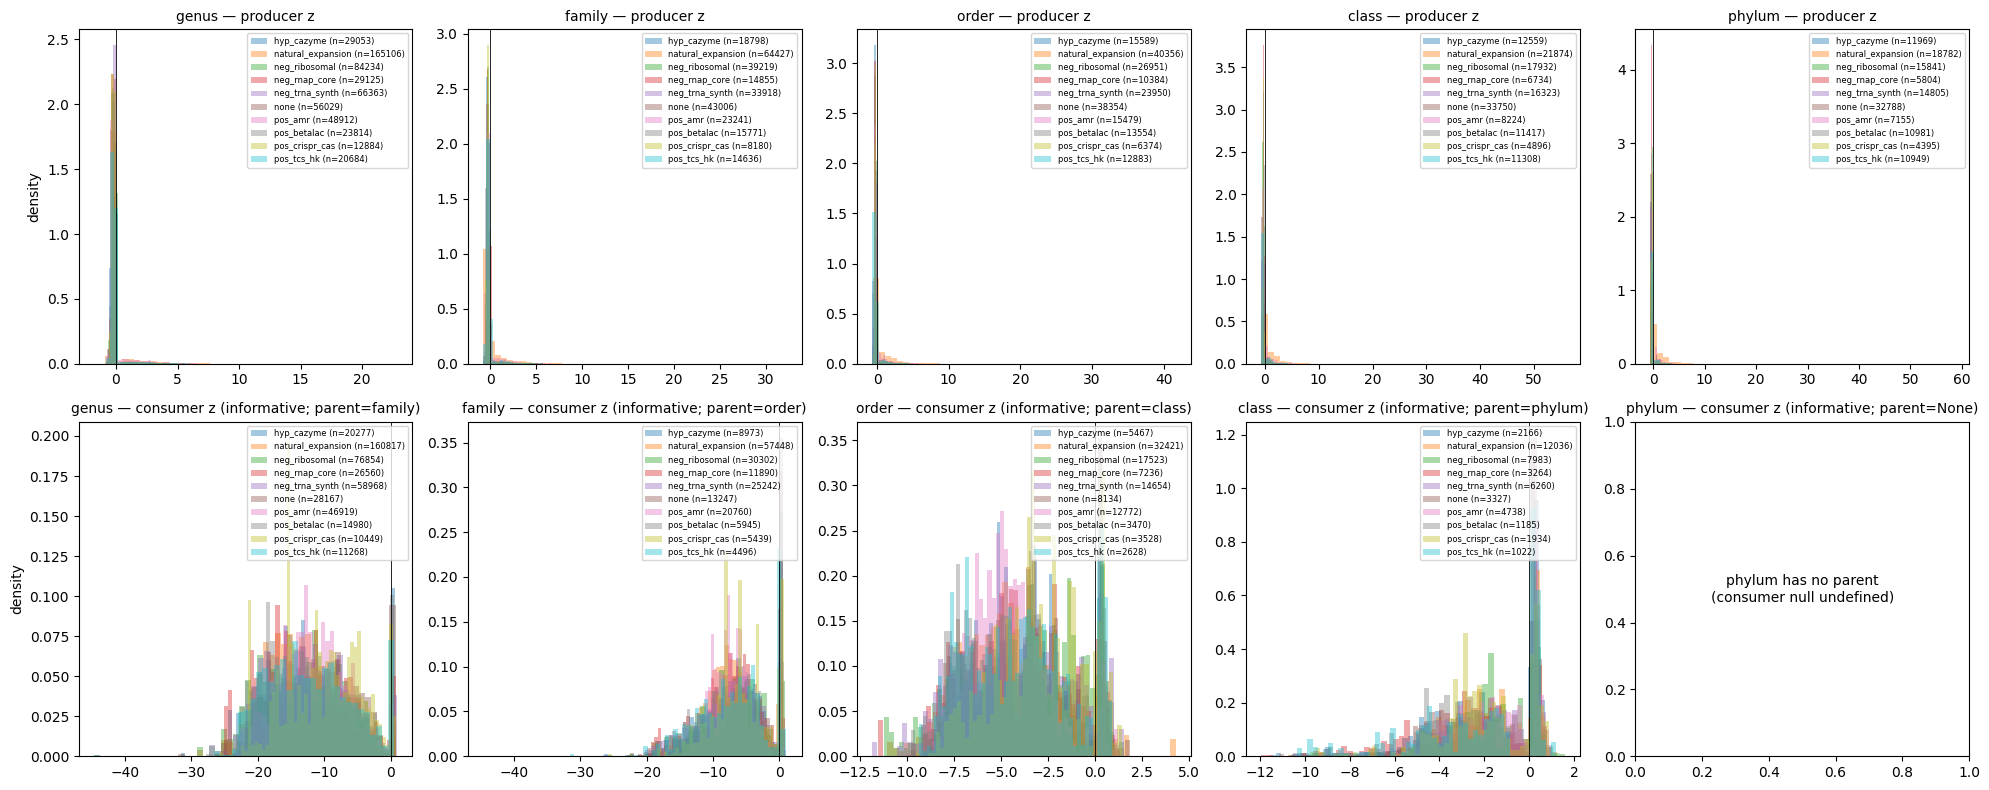

Saved figures/p1b_null_per_rank_distributions.png


In [10]:
fig, axes = plt.subplots(2, len(RANKS), figsize=(4 * len(RANKS), 8))
for col, rank in enumerate(RANKS):
    # Top: producer z by class
    ax = axes[0, col]
    sub = scores_df[scores_df["rank"] == rank]
    if len(sub) > 0:
        for cls in sorted(sub["control_class"].dropna().unique()):
            cls_sub = sub[sub["control_class"] == cls]
            if len(cls_sub) > 0:
                ax.hist(cls_sub["producer_z"], bins=50, alpha=0.4, label=f"{cls} (n={len(cls_sub)})", density=True)
    ax.axvline(0, color="black", lw=0.6)
    ax.set_title(f"{rank} — producer z", fontsize=10)
    if col == 0:
        ax.set_ylabel("density")
    ax.legend(fontsize=6, loc="upper right")

    # Bottom: consumer z (informative)
    ax = axes[1, col]
    if rank == "phylum":
        ax.text(0.5, 0.5, "phylum has no parent\n(consumer null undefined)",
               ha="center", va="center", transform=ax.transAxes, fontsize=10)
    elif len(sub) > 0:
        for cls in sorted(sub["control_class"].dropna().unique()):
            cls_sub = sub[(sub["control_class"] == cls) & (~sub["consumer_z_informative"].isna())]
            if len(cls_sub) > 0:
                ax.hist(cls_sub["consumer_z_informative"], bins=50, alpha=0.4, label=f"{cls} (n={len(cls_sub)})", density=True)
        ax.axvline(0, color="black", lw=0.6)
        ax.legend(fontsize=6, loc="upper right")
    ax.set_title(f"{rank} — consumer z (informative; parent={PARENT_RANK[rank]})", fontsize=10)
    if col == 0:
        ax.set_ylabel("density")

plt.tight_layout()
plt.savefig(FIG_DIR / "p1b_null_per_rank_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/p1b_null_per_rank_distributions.png")

## Summary

Phase 1B null model + per-(rank, clade, UniRef) score table materialized at full GTDB scale.

**Key methodological change vs Phase 1A**: M1 rank-stratified parents — consumer null at genus rank uses family as parent (not phylum); at family uses order; at order uses class; at class uses phylum. Phylum rank consumer null is undefined.

**Next**: NB07 — Bacteroidota PUL hypothesis test + atlas-level distributions + control validation under M2 revised criterion.